Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)



Preparing MSW dataset (Forced 6-dim alignment) 
Pre-flight check: Validating MSW CSV mapping...
--- MSW CSV RAW MEANS ---
  > Age     : 62.13
  > Sex     : 0.26
  > Dur     : 8.47
  > LEDD    : 989.80
  > Off-Pre : 45.91
  > On-Pre  : 19.60

Final MSW Breakdown:
 - Unique Subjects on Disk: 111
 - Labeled Responders (1): 61
 - Labeled Non-Responders (0): 5
 - Unlabeled subjects (-1): 45
 - Verified Realized Means (Matched Data Only):
    > Age     : 63.08
    > Sex     : 0.26
    > Dur     : 8.44
    > LEDD    : 1003.95
    > Off-Pre : 45.62
    > On-Pre  : 19.55

❌ FULL MISSING LIST (45 subjects):
  [3, 4, 5, 8, 12, 13, 14, 17, 18, 21, 22, 24, 25, 27, 28, 31, 32, 34, 35, 37, 39, 40, 41, 42, 49, 50, 52, 54, 57, 61, 65, 67, 74, 76, 81, 82, 84, 88, 89, 94, 99, 101, 104, 105, 116]
Loaded cache with 7790 slices.

Preparing CHH dataset (Forced 6-dim alignment) 
Pre-flight check: Validating CHH CSV mapping...
--- CHH CSV RAW MEANS ---
  > Age     : 63.13
  > Sex     : 0.46
  > Dur     : 8.54

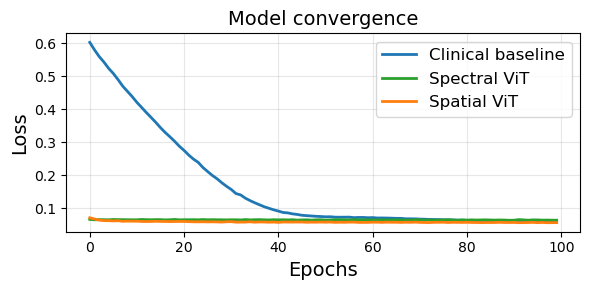

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
import numpy as np
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix
from scipy.stats import norm
from statsmodels.stats.contingency_tables import mcnemar
from reader import prepare_qsm_dataset
from util import seed_everything, mask_crop as mask_crop_fn
from train import calibrate_balanced
import matplotlib.pyplot as plt

# Configuration
device = torch.device("cuda:5" if torch.cuda.is_available() else "cpu")
N_PCA_COMPONENTS = []
N_FOLDS = 5 
NEG_WEIGHT = []
GAMMA = []
EPOCHS = 100
JITTER_STD = 0.1 
TARGET_DIM = 128
IMG_AUG_STD = 0.05
seed_everything(0)

# Statistical helper functions
def delong_roc_test(ground_truth, predictions_one, predictions_two):
    auc1 = roc_auc_score(ground_truth, predictions_one)
    auc2 = roc_auc_score(ground_truth, predictions_two)
    pos_mask, neg_mask = (ground_truth == 1), (ground_truth == 0)
    m, n = np.sum(pos_mask), np.sum(neg_mask)
    def get_components(preds):
        pos_preds, neg_preds = preds[pos_mask], preds[neg_mask]
        v10 = np.array([(np.sum(neg_preds < p) + 0.5 * np.sum(neg_preds == p)) / n for p in pos_preds])
        v01 = np.array([(np.sum(pos_preds > p) + 0.5 * np.sum(pos_preds == p)) / m for p in neg_preds])
        return v10, v01
    v10_1, v01_1 = get_components(predictions_one)
    v10_2, v01_2 = get_components(predictions_two)
    var1 = np.var(v10_1, ddof=1)/m + np.var(v01_1, ddof=1)/n
    var2 = np.var(v10_2, ddof=1)/m + np.var(v01_2, ddof=1)/n
    covariance = np.cov(v10_1, v10_2)[0,1]/m + np.cov(v01_1, v01_2)[0,1]/n
    se = np.sqrt(max(1e-10, var1 + var2 - 2 * covariance))
    z = (auc1 - auc2) / se
    return auc1, auc2, 2 * (1 - norm.cdf(np.abs(z)))

def perform_statistical_tests(y_true, prob_ct, prob_sp, prob_spatial, th_ct, th_sp, th_spatial):
    preds_ct = (prob_ct >= th_ct).astype(int)
    preds_sp = (prob_sp >= th_sp).astype(int)
    preds_spatial = (prob_spatial >= th_spatial).astype(int)
    def get_metrics(p_labels):
        acc = accuracy_score(y_true, p_labels)
        sens = recall_score(y_true, p_labels)
        tn, fp, fn, tp = confusion_matrix(y_true, p_labels, labels=[0, 1]).ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        return acc, sens, spec
    m_ct, m_sp, m_va = get_metrics(preds_ct), get_metrics(preds_sp), get_metrics(preds_spatial)
    auc_ct, auc_sp, auc_va = roc_auc_score(y_true, prob_ct), roc_auc_score(y_true, prob_sp), roc_auc_score(y_true, prob_spatial)
    def get_p_values(p1, p2, prob1, prob2):
        # Accuracy P-value (McNemar)
        # Where model 1 was correct vs where model 2 was correct
        cm_acc = confusion_matrix(p1 == y_true, p2 == y_true, labels=[0, 1])
        p_acc = mcnemar(cm_acc, exact=True).pvalue
        # Sensitivity P-value (McNemar on Positives)
        pos_idx = (y_true == 1)
        if np.any(pos_idx):
            cm_sens = confusion_matrix(p1[pos_idx] == 1, p2[pos_idx] == 1, labels=[0, 1])
            p_sens = mcnemar(cm_sens, exact=True).pvalue
        else:
            p_sens = np.nan
        # Specificity P-value (McNemar on Negatives)
        neg_idx = (y_true == 0)
        if np.any(neg_idx):
            cm_spec = confusion_matrix(p1[neg_idx] == 0, p2[neg_idx] == 0, labels=[0, 1])
            p_spec = mcnemar(cm_spec, exact=True).pvalue
        else:
            p_spec = np.nan
        # AUC P-value (DeLong)
        if np.array_equal(prob1, prob2):
            p_auc = 1.0
        else:
            try:
                _, _, p_auc = delong_roc_test(y_true, prob1, prob2)
            except:
                p_auc = np.nan
        return p_acc, p_sens, p_spec, p_auc
    p_sp_vs_ct = get_p_values(preds_ct, preds_sp, prob_ct, prob_sp)
    p_va_vs_ct = get_p_values(preds_ct, preds_spatial, prob_ct, prob_spatial)
    p_va_vs_sp = get_p_values(preds_sp, preds_spatial, prob_sp, prob_spatial)
    print(f"\n Model performance \n")
    # Define widths for consistency
    h_w = 22  # Width for the p-value columns to accommodate longer headers
    print(f"{'Metric':<12} | {'Clinical':<8} | {'Spectral':<8} | {'Spatial':<8} | {'p(Spectral, Clinical)':<{h_w}} | {'p(Spatial, Clinical)':<{h_w}} | {'p(Spatial, Spectral)':<{h_w}}")
    print("-" * (12 + 3 + 8 + 3 + 8 + 3 + 8 + 3 + h_w + 3 + h_w + 3 + h_w))
    names = ['Accuracy', 'Sensitivity', 'Specificity', 'AUC']
    v_ct, v_sp, v_va = [*m_ct, auc_ct], [*m_sp, auc_sp], [*m_va, auc_va]
    for i in range(4):
        print(f"{names[i]:<12} | {v_ct[i]:<8.3f} | {v_sp[i]:<8.3f} | {v_va[i]:<8.3f} | {p_sp_vs_ct[i]:<{h_w}.4f} | {p_va_vs_ct[i]:<{h_w}.4f} | {p_va_vs_sp[i]:<{h_w}.4f}")

# Architecture and loss classes
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, inputs, targets, weight=None):
        bce = F.binary_cross_entropy(inputs, targets, weight=weight, reduction='none')
        return (self.alpha * (1 - torch.exp(-bce))**self.gamma * bce).mean()

class ClinicalTransformer(nn.Module):
    def __init__(self, n_inputs, embed_dim=32, n_heads=4, n_layers=2):
        super().__init__()
        self.embedding = nn.Linear(1, embed_dim)
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim*2, dropout=0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.fc = nn.Linear(embed_dim * n_inputs, 1)
    def forward(self, x, return_logit=False):
        if x.ndim == 1: x = x.unsqueeze(0)
        x = self.embedding(x.unsqueeze(-1)).permute(1, 0, 2)
        x = self.transformer(x).permute(1, 0, 2).flatten(1)
        logit = self.fc(x).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

class SpectralViT(nn.Module):
    def __init__(self, n_inputs, n_heads=1, embed_dim=32, n_layers=1):
        super().__init__()
        # Initializing weights based on PCA Rank (1/rank)
        ranks = torch.arange(1, n_inputs + 1, dtype=torch.float32)
        self.rank_weights = nn.Parameter(1.0 / ranks)
        # Transformer encoder
        layer = nn.TransformerEncoderLayer(
            d_model=1,           # Each feature is a token
            nhead=n_heads,
            dim_feedforward=embed_dim*2,
            dropout = 0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.fc = nn.Linear(n_inputs, 1)
    def forward(self, x, return_logit=False):
        # Changed torch.exp to linear multiplication
        # Preserves rank-based weighting without saturating gradients.
        x_weighted = x * self.rank_weights
        # Transformer expects (seq_len, batch, feature_dim)
        x_seq = x_weighted.unsqueeze(-1).transpose(0, 1)  # [seq_len, batch, 1]
        x_trans = self.transformer(x_seq)
        x_trans_flat = x_trans.transpose(0, 1).squeeze(-1)  # [batch, n_inputs]
        logit = self.fc(x_trans_flat).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

class SpatialViT(nn.Module):
    def __init__(self, img_size=128, patch_size=16, embed_dim=32, n_heads=1, n_layers=1):
        super().__init__()
        self.patch_size, self.n_patches = patch_size, (img_size // patch_size) ** 2
        self.proj = nn.Linear(patch_size * patch_size, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim*2, dropout=0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.fc = nn.Linear(embed_dim, 1)
    def forward(self, x, return_logit=False):
        b = x.shape[0]
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        x = self.proj(x.contiguous().view(b, self.n_patches, -1)) + self.pos_embed
        x = self.transformer(x.permute(1, 0, 2)).permute(1, 0, 2).mean(dim=1)
        logit = self.fc(x).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

class ResidualSpectral(nn.Module):
    def __init__(self, m_ct, m_res):
        super().__init__()
        self.m_ct, self.m_res = m_ct, m_res
    def forward(self, x_res, x_clin, return_logit=False):
        with torch.no_grad(): l_clin = self.m_ct(x_clin, return_logit=True)
        l_res = self.m_res(x_res, return_logit=True)
        joint = l_clin + l_res
        return joint if return_logit else torch.sigmoid(joint)

class ResidualSpatial(nn.Module):
    def __init__(self, m_ct, m_res):
        super().__init__()
        self.m_ct, self.m_res = m_ct, m_res
    def forward(self, x_res, x_clin, return_logit=False):
        with torch.no_grad(): l_clin = self.m_ct(x_clin, return_logit=True)
        l_res = self.m_res(x_res, return_logit=True)
        joint = l_clin + l_res
        return joint if return_logit else torch.sigmoid(joint)

# Data preparation
def robust_flatten(img_np, target_dim=TARGET_DIM):
    t = torch.from_numpy(img_np).float().unsqueeze(0).unsqueeze(0)
    resized = F.interpolate(t, size=(target_dim, target_dim), mode='bilinear', align_corners=False)
    return resized.numpy().flatten()

def get_slice_level_data(dataset, include_unlabeled=False):
    all_imgs, all_clins, all_lbls, subj_map = [], [], [], []
    for i in range(len(dataset)):
        img, clin, lbl, _ = dataset[i]
        if (i % 72) in [0]: continue
        if (lbl != -1) or (include_unlabeled and lbl == -1):
            all_imgs.append(robust_flatten(img.numpy().squeeze()))
            all_clins.append(clin.numpy()); all_lbls.append(lbl); subj_map.append(i)
    return np.array(all_imgs), np.array(all_clins), np.array(all_lbls), np.array(subj_map)

dataset_msw = prepare_qsm_dataset('MSW', '/media/mts_dbs/dbs/all/nii/qsm_115/im', '/media/mts_dbs/dbs/all/nii/seg_ps/', '/data/Ali/RadDBS-QSM/data/docs/dbs_03292024.csv', 'msw_cache_6d_cv.pt', load_cache=True, mask_crop_fn=mask_crop_fn, cv_pad=False)
dataset_chh = prepare_qsm_dataset('CHH', '/media/mts_dbs/chh/nii/qsm/', '/media/mts_dbs/chh/roi/', '/media/mts_dbs/chh/xlsx/chh_subjects_table1_20240729.csv', 'chh_cache_6d_cv.pt', load_cache=True, mask_crop_fn=mask_crop_fn, cv_pad=False)

X_full_slices, X_full_clin, y_full_slices, full_subj_map = get_slice_level_data(dataset_msw, include_unlabeled=True)
labeled_mask = (y_full_slices != -1)
X_tr_slices, X_tr_clin, y_tr_slices, tr_subj_map = X_full_slices[labeled_mask], X_full_clin[labeled_mask], y_full_slices[labeled_mask], full_subj_map[labeled_mask]
NEG_WEIGHT = float(sum(y_tr_slices==1)//sum(y_tr_slices==0))
GAMMA = NEG_WEIGHT
print('Computed negative weight', NEG_WEIGHT, 'by training data class ratio')
X_te_slices, X_te_clin, y_te_slices, te_subj_map = get_slice_level_data(dataset_chh)
img_scaler = StandardScaler().fit(X_tr_slices)

# Cross-validation
unique_subjs = np.unique(tr_subj_map)
y_unique = np.array([y_tr_slices[tr_subj_map == s][0] for s in unique_subjs])
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=0)
fold_preds_ct, fold_preds_sp, fold_preds_spatial = [], [], []
fold_ths_ct, fold_ths_sp, fold_ths_spatial = [], [], []
criterion = FocalLoss(gamma=GAMMA)

# Hyperparameter selection
rng_state = torch.get_rng_state()
pca_components = [16, 32, 64, 128]
component_results = {k: [] for k in pca_components}

# Training
for n_comp in pca_components:    
    # PCA with `n_comp`
    pca_v = PCA(n_components=n_comp, random_state=0, whiten=True).fit(img_scaler.transform(X_tr_slices))
    X_tr_pca_v = pca_v.transform(img_scaler.transform(X_tr_slices))

    # Cross-fold evaluation
    for fold, (t_subj_idx, v_subj_idx) in enumerate(skf.split(unique_subjs, y_unique)):
        # Fold data
        t_idx = np.isin(tr_subj_map, unique_subjs[t_subj_idx])
        v_idx = np.isin(tr_subj_map, unique_subjs[v_subj_idx])
        
        xt_pca_v = torch.tensor(X_tr_pca_v[t_idx], dtype=torch.float32).to(device)
        yt_v = torch.tensor(y_tr_slices[t_idx], dtype=torch.float32).to(device)
        
        # Validation data
        xv_pca_v = torch.tensor(X_tr_pca_v[v_idx], dtype=torch.float32).to(device)
        yv_v = y_tr_slices[v_idx]

        # Model
        m_test = SpectralViT(n_inputs=n_comp).to(device)
        opt_test = optim.Adam(m_test.parameters(), lr=5e-4)
        
        # Train
        for _ in range(int(EPOCHS)):
            m_test.train(); opt_test.zero_grad()
            w = torch.where(yt_v == 0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(1.0).to(device))
            criterion(m_test(xt_pca_v), yt_v, weight=w).backward()
            opt_test.step()
        
        # 4. Score
        m_test.eval()
        with torch.no_grad():
            v_probs = m_test(xv_pca_v).cpu().numpy()
            # Per-subject mean pooling
            v_subj_probs = []
            v_subj_labels = []
            for s_id in unique_subjs[v_subj_idx]:
                s_mask = (tr_subj_map[v_idx] == s_id)
                v_subj_probs.append(v_probs[s_mask].mean())
                v_subj_labels.append(yv_v[s_mask][0])
            
            fold_auc = roc_auc_score(v_subj_labels, v_subj_probs)
            component_results[n_comp].append(fold_auc)

N_PCA_COMPONENTS = pca_components[np.argmin([np.std(component_results[n]) for n in pca_components])]
print('Selected PCA components', N_PCA_COMPONENTS, 'by cross-validation')

# Cross-validation to find majority class weight
pos_weight_variants = [0.1, 0.25, 0.5, 0.75, 1.0]
weight_results = {k: [] for k in pos_weight_variants}
for p_weight in pos_weight_variants:
    
    for fold, (t_subj_idx, v_subj_idx) in enumerate(skf.split(unique_subjs, y_unique)):
        # Fold mask
        t_mask = np.isin(tr_subj_map, unique_subjs[t_subj_idx])
        v_mask = np.isin(tr_subj_map, unique_subjs[v_subj_idx])
        
        # Scale clinical features
        scaler_weight_test = StandardScaler().fit(X_tr_clin[t_mask])
        xt_c_t = torch.tensor(scaler_weight_test.transform(X_tr_clin[t_mask]), dtype=torch.float32).to(device)
        yt_t = torch.tensor(y_tr_slices[t_mask], dtype=torch.float32).to(device)
        
        # Validation data
        xv_c_v = torch.tensor(scaler_weight_test.transform(X_tr_clin[v_mask]), dtype=torch.float32).to(device)
        yv_v = y_tr_slices[v_mask]

        # Initialize model
        m_weight_test = ClinicalTransformer(n_inputs=X_tr_clin.shape[1]).to(device)
        opt_weight_test = optim.Adam(m_weight_test.parameters(), lr=5e-4)
        
        # Define weight tensor using `NEG_WEIGHT` for class 0 (non-responder), `p_weight` for class 1 (responder)
        w_tensor = torch.where(yt_t == 0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(p_weight).to(device))
        
        # Train
        for _ in range(int(EPOCHS)):
            m_weight_test.train(); opt_weight_test.zero_grad()
            # Apply Jitter
            x_j = xt_c_t + torch.randn_like(xt_c_t) * JITTER_STD
            criterion(m_weight_test(x_j), yt_t, weight=w_tensor).backward()
            opt_weight_test.step()
        
        # Evaluate
        m_weight_test.eval()
        with torch.no_grad():
            v_probs = m_weight_test(xv_c_v).cpu().numpy()
            v_subj_probs = []
            v_subj_labels = []
            for s_id in unique_subjs[v_subj_idx]:
                s_mask = (tr_subj_map[v_mask] == s_id)
                v_subj_probs.append(v_probs[s_mask].mean())
                v_subj_labels.append(yv_v[s_mask][0])
            
            fold_auc = roc_auc_score(v_subj_labels, v_subj_probs)
            weight_results[p_weight].append(fold_auc)

# Select best weight based on AUC stability
SELECTED_POS_WEIGHT = pos_weight_variants[np.argmin([np.std(weight_results[pw]) for pw in pos_weight_variants])]
print(f"Selected positive weight {SELECTED_POS_WEIGHT} by cross-validation")
torch.set_rng_state(rng_state) 

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=0, whiten=True).fit(img_scaler.transform(X_tr_slices))
X_tr_pca, X_te_pca = pca.transform(img_scaler.transform(X_tr_slices)), pca.transform(img_scaler.transform(X_te_slices))

class PassThrough(nn.Module):
    def forward(self, x, **kwargs): return x

# Loss lists
epochs = 100
all_folds_loss_ct = np.zeros(epochs)
all_folds_loss_sp = np.zeros(epochs)
all_folds_loss_va = np.zeros(epochs)

for fold, (t_subj_idx, v_subj_idx) in enumerate(skf.split(unique_subjs, y_unique)):
    print(f'Fold {fold} Training...')
    t_mask = np.isin(tr_subj_map, unique_subjs[t_subj_idx])
    v_mask = np.isin(tr_subj_map, unique_subjs[v_subj_idx])
    
    scaler_c = StandardScaler().fit(X_tr_clin[t_mask])
    xt_c = torch.tensor(scaler_c.transform(X_tr_clin[t_mask]), dtype=torch.float32).to(device)
    yt = torch.tensor(y_tr_slices[t_mask], dtype=torch.float32).to(device)
    w = torch.where(yt==0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(SELECTED_POS_WEIGHT).to(device))

    # Clinical transformer
    m_ct = ClinicalTransformer(n_inputs=X_tr_clin.shape[1]).to(device)
    opt_ct = optim.Adam(m_ct.parameters(), lr=1e-4)
    for _ in range(EPOCHS):
        m_ct.train(); opt_ct.zero_grad()
        loss = criterion(m_ct(xt_c + torch.randn_like(xt_c)*JITTER_STD), yt, weight=w)
        loss.backward(); opt_ct.step()
        all_folds_loss_ct[_] += loss.item() / N_FOLDS
    m_ct.eval(); [p.requires_grad_(False) for p in m_ct.parameters()]

    # Spectral ViT
    m_sp = ResidualSpectral(m_ct, SpectralViT(n_inputs=N_PCA_COMPONENTS)).to(device)
    opt_sp = optim.Adam(m_sp.m_res.parameters(), lr=1e-4)
    xt_pca = torch.tensor(X_tr_pca[t_mask], dtype=torch.float32).to(device)
    for _ in range(EPOCHS):
        m_sp.train(); opt_sp.zero_grad()
        p = m_sp(xt_pca + torch.randn_like(xt_pca)*IMG_AUG_STD, xt_c + torch.randn_like(xt_c)*JITTER_STD)
        loss = criterion(p, yt, weight=w)
        loss.backward(); opt_sp.step()
        all_folds_loss_sp[_] += loss.item() / N_FOLDS

    # Spatial ViT
    m_va = ResidualSpatial(m_ct, SpatialViT()).to(device)
    opt_va = optim.Adam(m_va.m_res.parameters(), lr=1e-4)
    xt_img = torch.tensor(X_tr_slices[t_mask]).view(-1, 1, 128, 128).float().to(device)
    for _ in range(EPOCHS):
        m_va.train(); opt_va.zero_grad()
        p = m_va(xt_img + torch.randn_like(xt_img)*IMG_AUG_STD, xt_c + torch.randn_like(xt_c)*JITTER_STD)
        loss = criterion(p, yt, weight=w)
        loss.backward(); opt_va.step()
        all_folds_loss_va[_] += loss.item() / N_FOLDS

    # Balanced accuacy threshold calibration
    m_sp.eval(); m_va.eval()
    with torch.no_grad():
        v_ct, v_sp, v_va, v_lbls = [], [], [], []
        for s_id in unique_subjs[v_subj_idx]:
            sm = (tr_subj_map == s_id)
            c = torch.tensor(scaler_c.transform(X_tr_clin[sm]), dtype=torch.float32).to(device)
            p_in = torch.tensor(X_tr_pca[sm], dtype=torch.float32).to(device)
            i_in = torch.tensor(X_tr_slices[sm]).view(-1, 1, 128, 128).float().to(device)
            v_ct.append(m_ct(c).mean().item())
            v_sp.append(m_sp(p_in, c).mean().item())
            v_va.append(m_va(i_in, c).mean().item())
            v_lbls.append(y_tr_slices[sm][0])
            
    fold_ths_ct.append(calibrate_balanced(PassThrough(), None, np.array(v_ct), np.array(v_lbls), 'cpu'))
    fold_ths_sp.append(calibrate_balanced(PassThrough(), None, np.array(v_sp), np.array(v_lbls), 'cpu'))
    fold_ths_spatial.append(calibrate_balanced(PassThrough(), None, np.array(v_va), np.array(v_lbls), 'cpu'))

    # Inference
    with torch.no_grad():
        t_ct, t_sp, t_va = [], [], []
        for s_id in np.unique(te_subj_map):
            sm = (te_subj_map == s_id)
            c = torch.tensor(scaler_c.transform(X_te_clin[sm]), dtype=torch.float32).to(device)
            p_in = torch.tensor(X_te_pca[sm], dtype=torch.float32).to(device)
            i_in = torch.tensor(X_te_slices[sm]).view(-1, 1, 128, 128).float().to(device)
            t_ct.append(m_ct(c).mean().item()); t_sp.append(m_sp(p_in, c).mean().item()); t_va.append(m_va(i_in, c).mean().item())
        fold_preds_ct.append(t_ct); fold_preds_sp.append(t_sp); fold_preds_spatial.append(t_va)

# Results
y_te_u = np.array([y_te_slices[te_subj_map == s][0] for s in np.unique(te_subj_map)])
p_ct, p_sp, p_va = np.mean(fold_preds_ct, 0), np.mean(fold_preds_sp, 0), np.mean(fold_preds_spatial, 0)
th_ct, th_sp, th_va = np.mean(fold_ths_ct), np.mean(fold_ths_sp), np.mean(fold_ths_spatial)

perform_statistical_tests(y_te_u, p_ct, p_sp, p_va, th_ct, th_sp, th_va)

plt.figure(figsize=(6, 3))
plt.plot(all_folds_loss_ct, label='Clinical baseline', color='tab:blue', linewidth=2)
plt.plot(all_folds_loss_sp, label='Spectral ViT', color='tab:green', linewidth=2)
plt.plot(all_folds_loss_va, label='Spatial ViT', color='tab:orange', linewidth=2)

plt.title('Model convergence', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

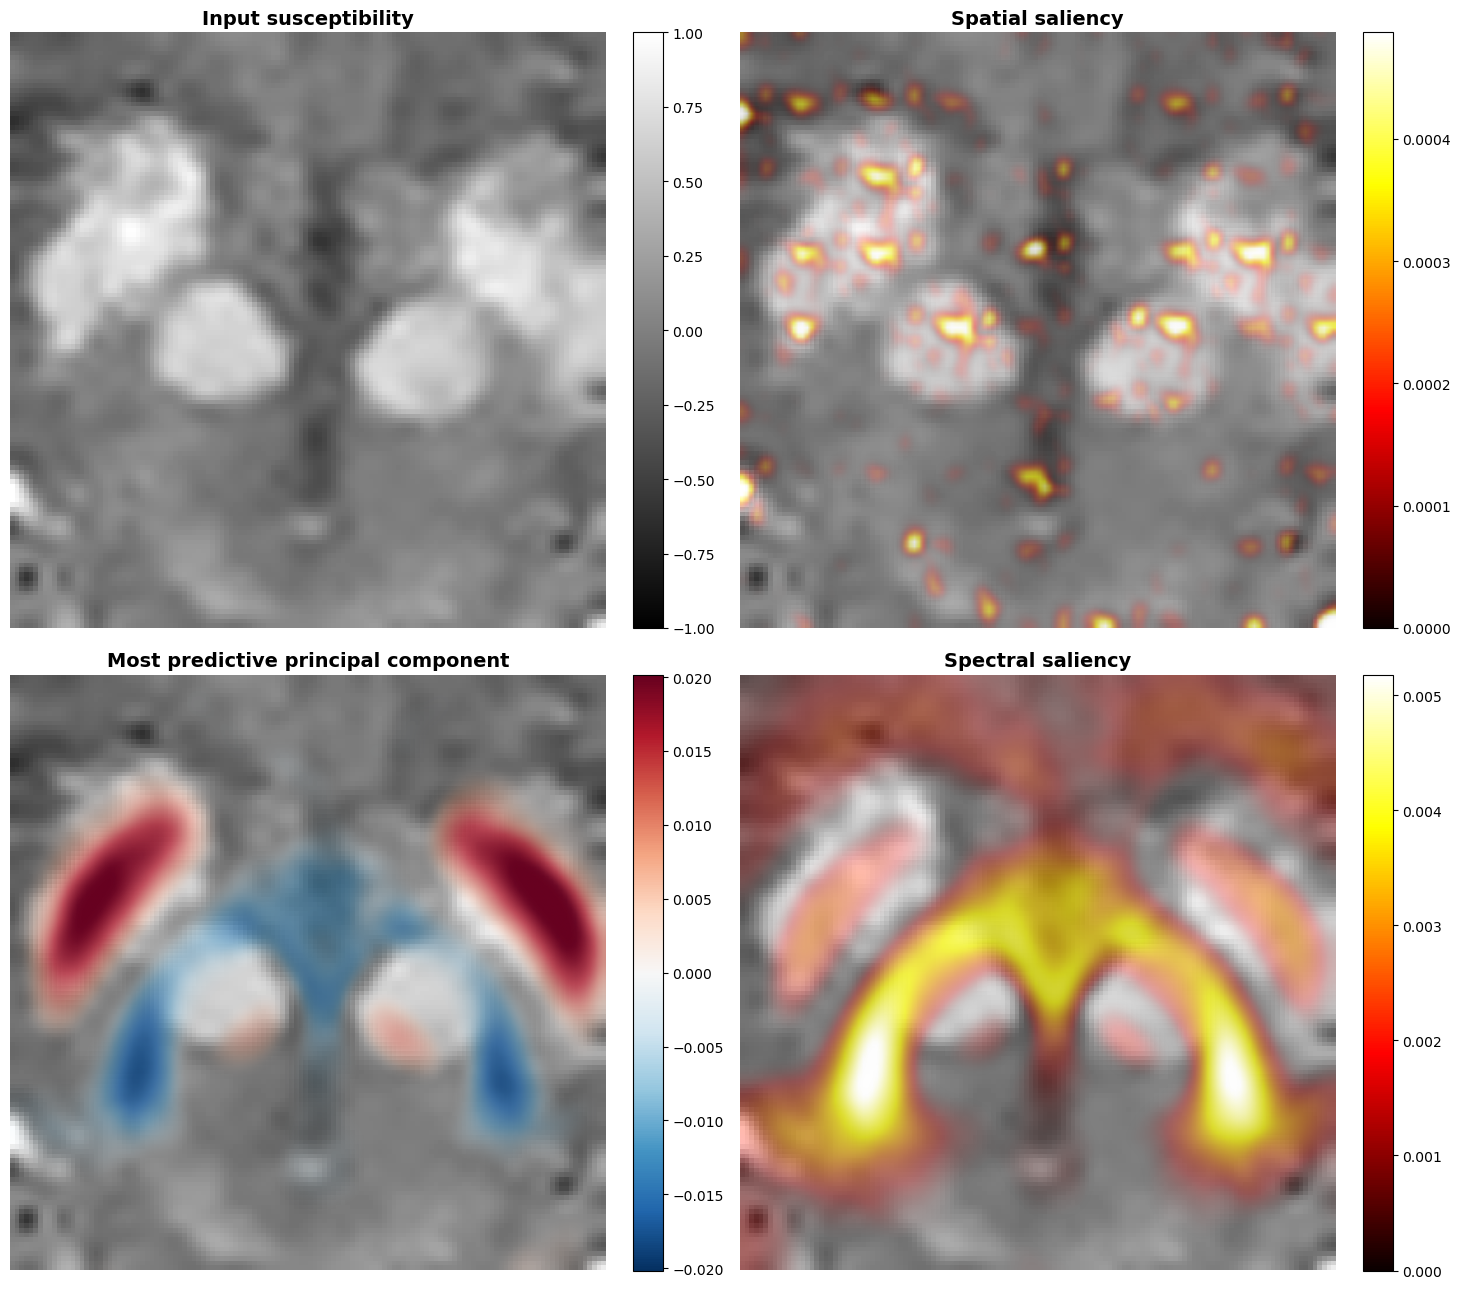

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

# Continuous architecture
class SpectralViT(nn.Module):
    def __init__(self, n_inputs, n_heads=1, embed_dim=32):
        super().__init__()
        ranks = torch.arange(1, n_inputs + 1, dtype=torch.float32)
        self.rank_weights = nn.Parameter(1.0 / ranks)
        encoder_layer = nn.TransformerEncoderLayer(d_model=1, nhead=n_heads, dim_feedforward=embed_dim*2, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc = nn.Linear(n_inputs, 1)

    def forward(self, x, return_logit=False):
        x_weighted = x * self.rank_weights
        x_seq = x_weighted.reshape(x.shape[1], x.shape[0], 1)
        x_trans = self.transformer(x_seq)
        x_trans_flat = x_trans.permute(1, 0, 2).reshape(x.shape[0], -1)
        logit = self.fc(x_trans_flat).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

# Visualization
def viz(pca_model, m_sp, m_va, X_te_raw, X_te_pca, X_te_clin, scaler_c):
    m_sp.eval(); m_va.eval()
    device = next(m_sp.parameters()).device
    idx = 40 

    # Data preparation
    xc_t = torch.from_numpy(scaler_c.transform(X_te_clin[idx:idx+1])).float().to(device)
    xp_t = torch.from_numpy(X_te_pca[idx:idx+1]).float().to(device).requires_grad_(True)
    xi_t = torch.from_numpy(X_te_raw[idx:idx+1]).view(-1, 1, 128, 128).float().to(device).requires_grad_(True)

    # Compute
    raw_w = m_sp.m_res.fc.weight.detach().cpu().numpy().squeeze()
    rank_w = m_sp.m_res.rank_weights.detach().cpu().numpy()
    pca_saliency = raw_w * rank_w * xp_t.detach().cpu().numpy().squeeze()
    
    spec_map = np.zeros((128, 128))
    for i in range(len(pca_saliency)):
        spec_map += pca_saliency[i] * pca_model.components_[i].reshape(128, 128)
    
    top_pc_idx = np.argmax(np.abs(pca_saliency))
    top_pc_img = pca_model.components_[top_pc_idx].reshape(128, 128)
    
    m_va.zero_grad()
    l_va = m_va(xi_t, xc_t, return_logit=True)
    grad_va = torch.autograd.grad(l_va.sum(), xi_t)[0]
    spat_map = (grad_va * xi_t).detach().cpu().numpy().squeeze()

    # Make zero values transparent
    def get_true_zero_cmap(base_cmap_name, is_diverging=False):
        base_cmap = plt.get_cmap(base_cmap_name)
        n = 256
        colors = base_cmap(np.arange(n))
        if is_diverging:
            alphas = np.abs(np.linspace(-1, 1, n))
            alphas = np.where(alphas < 0.2, 0, (alphas - 0.2) / 0.8) 
        else:
            alphas = np.linspace(0, 1, n)
            alphas = np.where(alphas < 0.15, 0, (alphas - 0.15) / 0.85)
        colors[:, -1] = alphas
        return mcolors.ListedColormap(colors)

    # Make plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 13), facecolor='white')
    bg = np.rot90(X_te_raw[idx].reshape(128, 128), k=1)

    def plot_maps(ax, data, title, cmap_name, p=99.7, is_pc=False):
        data_rot = np.rot90(data, k=1)
        ax.imshow(bg, cmap='gray', vmin=-1, vmax=1) 
        
        # Colormaps
        if is_pc:
            v = np.percentile(np.abs(data_rot), p) + 1e-12
            norm = mcolors.TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
            cmap = get_true_zero_cmap(cmap_name, is_diverging=True)
            plot_data = data_rot
        else:
            v = np.percentile(np.abs(data_rot), p) + 1e-12
            norm = mcolors.Normalize(vmin=0, vmax=v)
            cmap = get_true_zero_cmap(cmap_name, is_diverging=False)
            plot_data = np.abs(data_rot)
        
        # Smooths transparency
        rgba_img = cmap(norm(plot_data))
        rgba_img[:, :, 3] = gaussian_filter(rgba_img[:, :, 3], sigma=1.0)
        
        # Plot
        ax.imshow(rgba_img, interpolation='bilinear')
        
        sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap_name), norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.yaxis.set_tick_params(color='black', labelcolor='black')
        
        ax.set_title(title, fontweight='bold', fontsize=14, color='black')
        ax.axis('off')

    # Input
    axes[0, 0].imshow(bg, cmap='gray', vmin=-1, vmax=1)
    sm0 = plt.cm.ScalarMappable(cmap='gray', norm=mcolors.Normalize(-1, 1))
    fig.colorbar(sm0, ax=axes[0, 0], fraction=0.046, pad=0.04)
    axes[0, 0].set_title("Input susceptibility", fontweight='bold', fontsize=14); axes[0, 0].axis('off')

    # Spatial ViT
    plot_maps(axes[0, 1], gaussian_filter(spat_map, 1.5), "Spatial saliency", "hot")
    
    # Predictive principal component
    plot_maps(axes[1, 0], top_pc_img, f"Most predictive principal component", "RdBu_r", p=99, is_pc=True)
    
    # Spectral ViT
    plot_maps(axes[1, 1], gaussian_filter(spec_map, 1.5), "Spectral saliency", "hot")

    plt.tight_layout()
    plt.show()

viz(pca, m_sp, m_va, X_te_slices, X_te_pca, X_te_clin, scaler_c)

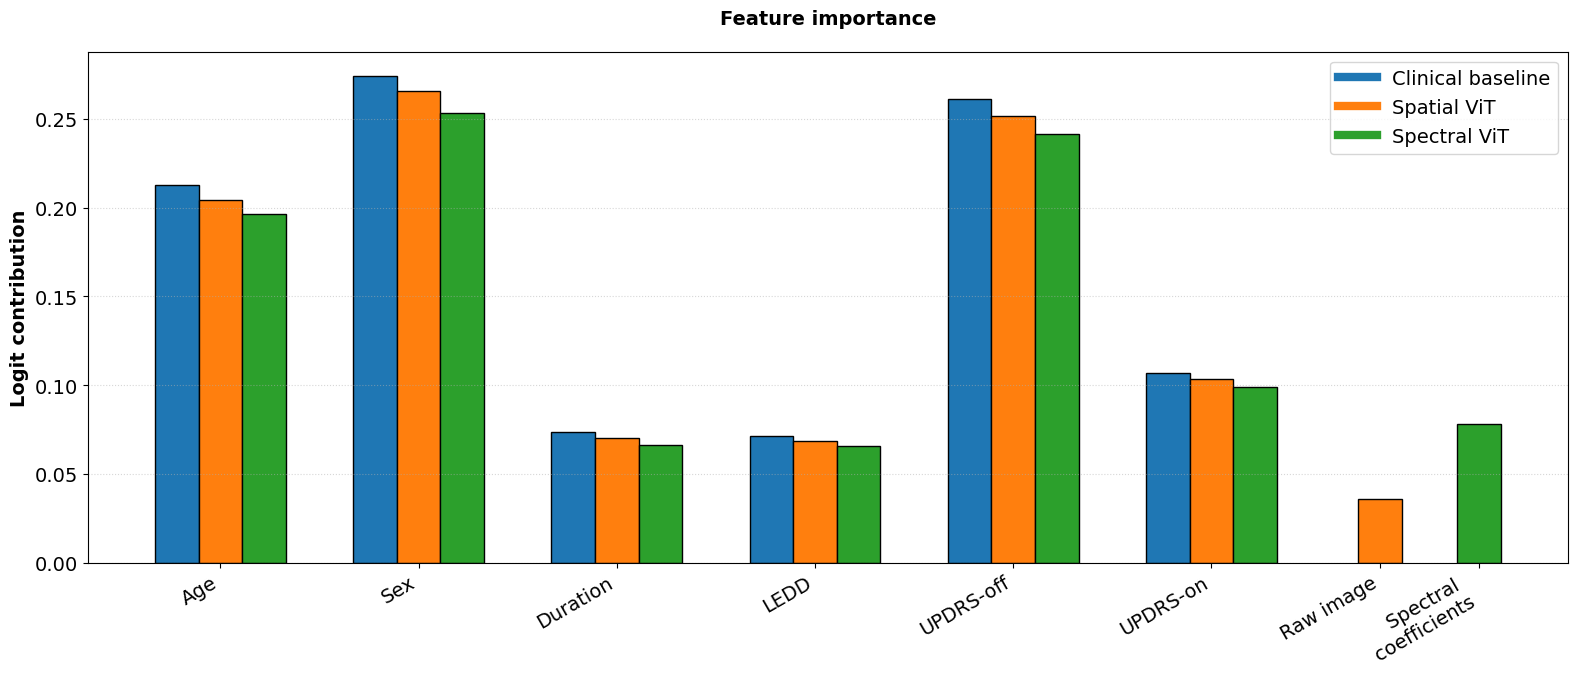

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.lines import Line2D

def plot_triple_model_contribution(clinical_model, spectral_model, spatial_model, x_clin_raw, x_pca, x_raw_images, scaler):
    # Allow gradients but not drop out
    for m in [clinical_model, spectral_model, spatial_model]:
        m.train()
        for module in m.modules():
            if isinstance(module, torch.nn.Dropout): module.p = 0 
            
    device = next(spectral_model.parameters()).device
    x_clin_scaled = scaler.transform(x_clin_raw)

    def get_logit_influence(model, xc, xp=None, xi=None):
        xc_t = torch.from_numpy(xc).float().to(device)
        
        with torch.no_grad():
            # Check model type
            if hasattr(model, 'm_ct'):
                # ViT
                l_clin = model.m_ct(xc_t, return_logit=True).abs().mean().item()
                clinical_module = model.m_ct
            else:
                # Baseline clinical
                l_clin = model(xc_t, return_logit=True).abs().mean().item()
                clinical_module = model

            if xi is not None: # Spatial
                xi_t = torch.from_numpy(xi).view(-1, 1, 128, 128).float().to(device)
                l_res = model.m_res(xi_t, return_logit=True).abs().mean().item()
            elif xp is not None: # Spectral
                xp_t = torch.from_numpy(xp).float().to(device)
                l_res = model.m_res(xp_t, return_logit=True).abs().mean().item()
            else: # Clinical
                l_res = 0

        # Gradients for the clinical variables
        xc_t.requires_grad_(True)
        clinical_module(xc_t, return_logit=True).sum().backward()
        c_pattern = xc_t.grad.abs().mean(dim=0).cpu().numpy()
        
        return c_pattern, l_clin, l_res

    # Influence
    cp_clin, cl_clin, _ = get_logit_influence(clinical_model, x_clin_scaled)
    sp_clin, sl_clin, sl_res = get_logit_influence(spatial_model, x_clin_scaled, xi=x_raw_images)
    pp_clin, pl_clin, pl_res = get_logit_influence(spectral_model, x_clin_scaled, xp=x_pca)

    # Normalize
    def scale_to_sum(pattern, clin_logit, res_logit):
        total = clin_logit + res_logit + 1e-12
        scaled_clin = (pattern / (np.sum(pattern) + 1e-12)) * (clin_logit / total)
        scaled_res = res_logit / total
        return scaled_clin, scaled_res

    c_f, _ = scale_to_sum(cp_clin, cl_clin, 0)
    s_clin_f, s_img_f = scale_to_sum(sp_clin, sl_clin, sl_res)
    p_clin_f, p_img_f = scale_to_sum(pp_clin, pl_clin, pl_res)

    # Plot parameters
    clin_names = ['Age', 'Sex', 'Duration', 'LEDD', 'UPDRS-off', 'UPDRS-on']
    fig, ax = plt.subplots(figsize=(16, 7), facecolor='white')
    width = 0.22 
    indices = np.arange(len(clin_names))
    c_blue = 'tab:blue'
    c_orange = 'tab:orange'
    c_green = 'tab:green'

    # Plot
    ax.bar(indices - width, c_f, width, color=c_blue, edgecolor='black')
    ax.bar(indices, s_clin_f, width, color=c_orange, edgecolor='black')
    ax.bar(indices + width, p_clin_f, width, color=c_green, edgecolor='black')

    # Aggregated imaging
    img_indices = [len(clin_names) - 0.15, len(clin_names) + 0.35]
    ax.bar(img_indices[0], s_img_f, width, color=c_orange, edgecolor='black')
    ax.bar(img_indices[1], p_img_f, width, color=c_green, edgecolor='black')

    # Formatting
    plt.rcParams.update({'font.size': 14}) # Global font size
    ax.set_xticks(list(indices) + img_indices)
    ax.set_xticklabels(clin_names + ['Raw image', 'Spectral \n coefficients'], rotation=30, ha='right', fontsize=14)
    
    ax.set_ylabel("Logit contribution", fontweight='bold', fontsize=14)
    ax.set_title("Feature importance", fontsize=14, pad=20, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Legend
    custom_lines = [
        Line2D([0], [0], color=c_blue, lw=6, label='Clinical baseline'),
        Line2D([0], [0], color=c_orange, lw=6, label='Spatial ViT'),
        Line2D([0], [0], color=c_green, lw=6, label='Spectral ViT')
    ]
    ax.legend(handles=custom_lines, loc='upper right', frameon=True, shadow=False, fontsize=14)
    
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Run
plot_triple_model_contribution(m_ct, m_sp, m_va, X_te_clin, X_te_pca, X_te_slices, scaler_c)

In [4]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Initialize models for a single instance to count parameters
# Using N_PCA_COMPONENTS selected by your CV logic
n_clinical_feats = X_tr_clin.shape[1]

model_baseline = ClinicalTransformer(n_inputs=n_clinical_feats).to(device)
model_spectral = SpectralViT(n_inputs=N_PCA_COMPONENTS).to(device)
model_spatial = SpatialViT().to(device)

# Residual wrappers (counting only the residual/vision component as that is the "addition")
res_spectral = ResidualSpectral(model_baseline, model_spectral)
res_spatial = ResidualSpatial(model_baseline, model_spatial)

models_info = [
    ("Clinical Transformer", model_baseline),
    ("Spectral ViT (Core)", model_spectral),
    ("Spatial ViT (Core)", model_spatial),
    ("Total Spectral System", res_spectral),
    ("Total Spatial System", res_spatial)
]

print(f"{'Architecture':<25} | {'Total Parameters':<18} | {'Seq Length (Tokens)':<20}")
print("-" * 70)

for name, model in models_info:
    params = count_parameters(model)
    
    # Determine token count (Sequence Length)
    if "Spectral" in name:
        tokens = N_PCA_COMPONENTS
    elif "Spatial" in name:
        tokens = (128 // 16) ** 2  # img_size // patch_size squared
    elif "Clinical" in name:
        tokens = n_clinical_feats
    else:
        tokens = "N/A"
        
    print(f"{name:<25} | {params:<18,} | {tokens:<20}")

# Efficiency Analysis
spectral_params = count_parameters(model_spectral)
spatial_params = count_parameters(model_spatial)
ratio = spatial_params / spectral_params

print(f"\nEfficiency Note: The Spectral ViT core is {ratio:.2f}x smaller than the Spatial ViT core.")

Architecture              | Total Parameters   | Seq Length (Tokens) 
----------------------------------------------------------------------
Clinical Transformer      | 17,345             | 6                   
Spectral ViT (Core)       | 238                | 16                  
Spatial ViT (Core)        | 18,849             | 64                  
Total Spectral System     | 17,583             | 16                  
Total Spatial System      | 36,194             | 64                  

Efficiency Note: The Spectral ViT core is 79.20x smaller than the Spatial ViT core.
